<a href="https://colab.research.google.com/github/apurvakumbhar/Deep_Learning/blob/main/DLExperiment_01(A).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

X = np.ones((100, 1))
y = np.ones((100, 1)) * 0.5

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1 - np.tanh(x) ** 2

def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

def train(case):
    layers = 10
    weights = []

    for _ in range(layers):
        if case == "vanishing":
            weights.append(np.random.randn(1, 1) * 0.01)
        elif case == "exploding":
            weights.append(np.random.randn(1, 1) * 5)
        elif case == "symmetry":
            weights.append(np.ones((1, 1)) * 0.5)
        elif case == "sigmoid_xavier":
            weights.append(np.random.randn(1, 1) * np.sqrt(1))
        elif case == "tanh_xavier":
            weights.append(np.random.randn(1, 1) * np.sqrt(1))
        elif case == "relu_he":
            weights.append(np.random.randn(1, 1) * np.sqrt(2))

    gradients = []

    a = X
    z_list = []

    for w in weights:
        z = a @ w

        if case == "relu_he":
            a = relu(z)
        elif case == "tanh_xavier":
            a = tanh(z)
        else:
            a = sigmoid(z)

        z_list.append(z)

    da = (a - y)

    for i in reversed(range(layers)):
        if case == "relu_he":
            dz = da * relu_deriv(z_list[i])
        elif case == "tanh_xavier":
            dz = da * tanh_deriv(z_list[i])
        else:
            dz = da * sigmoid_deriv(z_list[i])

        gradients.append(np.mean(np.abs(dz)))
        da = dz @ weights[i].T

    return gradients[::-1]

cases = [
    "vanishing",
    "exploding",
    "symmetry",
    "sigmoid_xavier",
    "tanh_xavier",
    "relu_he"
]

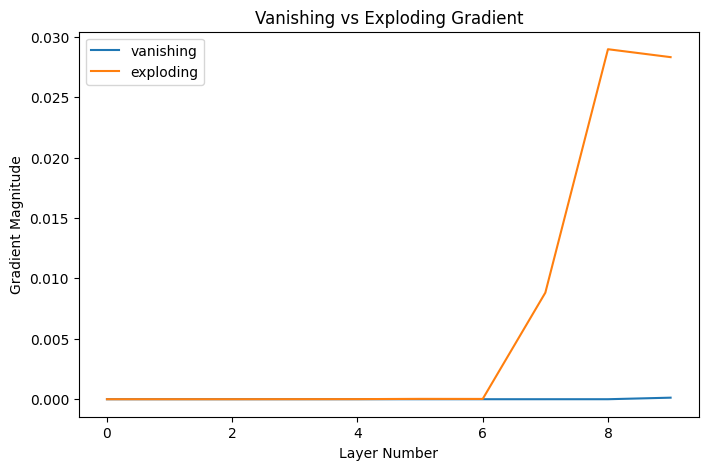

In [ ]:
plt.figure(figsize=(8,5))
for c in ["vanishing", "exploding"]:
    grads = train(c)
    plt.plot(grads, label=c)
plt.xlabel("Layer Number")
plt.ylabel("Gradient Magnitude")
plt.title("Vanishing vs Exploding Gradient")
plt.legend()
plt.show()

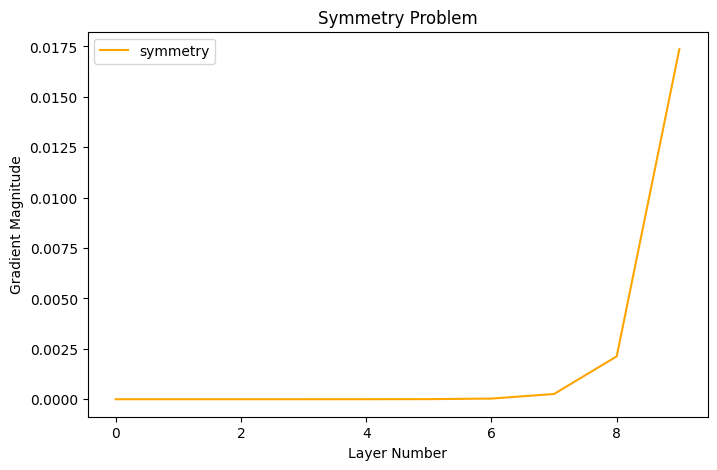

In [ ]:
plt.figure(figsize=(8,5))
grads = train("symmetry")
plt.plot(grads, label="symmetry", color="orange")
plt.xlabel("Layer Number")
plt.ylabel("Gradient Magnitude")
plt.title("Symmetry Problem")
plt.legend()
plt.show()

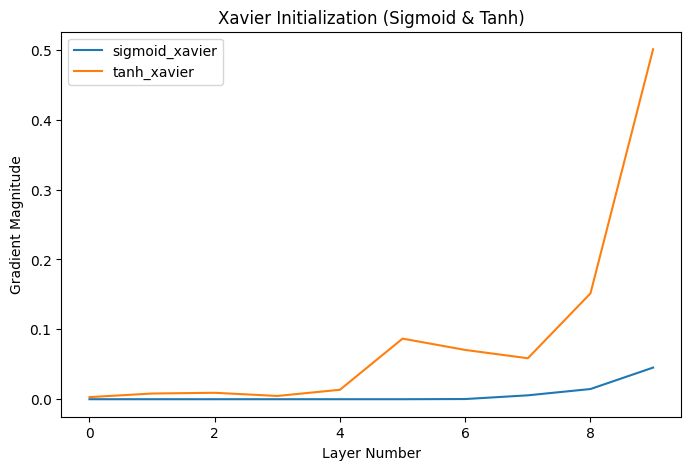

In [ ]:
plt.figure(figsize=(8,5))
for c in ["sigmoid_xavier", "tanh_xavier"]:
    grads = train(c)
    plt.plot(grads, label=c)
plt.xlabel("Layer Number")
plt.ylabel("Gradient Magnitude")
plt.title("Xavier Initialization (Sigmoid & Tanh)")
plt.legend()
plt.show()

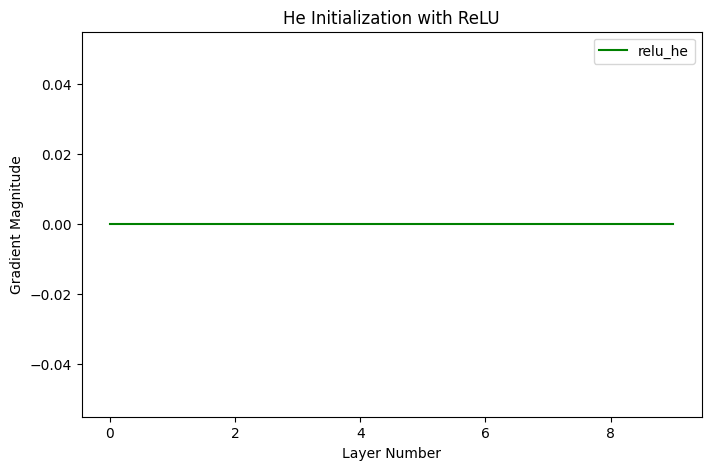

In [ ]:
plt.figure(figsize=(8,5))
grads = train("relu_he")
plt.plot(grads, label="relu_he", color="green")
plt.xlabel("Layer Number")
plt.ylabel("Gradient Magnitude")
plt.title("He Initialization with ReLU")
plt.legend()
plt.show()